In [1]:
#dqn

In [2]:
#https://github.com/openai/gym/blob/master/gym/envs/classic_control/acrobot.py

In [3]:
#https://github.com/eugeniaring/Medium-Articles/blob/main/Pytorch/acrobot.ipynb

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pickle

In [6]:
"""classic Acrobot task"""
from typing import Optional

import numpy as np
from numpy import cos, pi, sin

np.float_ = np.float64

from gym import core, logger, spaces
from gym.error import DependencyNotInstalled

__copyright__ = "Copyright 2013, RLPy http://acl.mit.edu/RLPy"
__credits__ = [
    "Alborz Geramifard",
    "Robert H. Klein",
    "Christoph Dann",
    "William Dabney",
    "Jonathan P. How",
]
__license__ = "BSD 3-Clause"
__author__ = "Christoph Dann <cdann@cdann.de>"

# SOURCE:
# https://github.com/rlpy/rlpy/blob/master/rlpy/Domains/Acrobot.py
from gym.envs.classic_control import utils


class Custom_AcrobotEnv(core.Env):
    """
    ### Description
    The Acrobot environment is based on Sutton's work in
    ["Generalization in Reinforcement Learning: Successful Examples Using Sparse Coarse Coding"](https://papers.nips.cc/paper/1995/hash/8f1d43620bc6bb580df6e80b0dc05c48-Abstract.html)
    and [Sutton and Barto's book](http://www.incompleteideas.net/book/the-book-2nd.html).
    The system consists of two links connected linearly to form a chain, with one end of
    the chain fixed. The joint between the two links is actuated. The goal is to apply
    torques on the actuated joint to swing the free end of the linear chain above a
    given height while starting from the initial state of hanging downwards.
    As seen in the **Gif**: two blue links connected by two green joints. The joint in
    between the two links is actuated. The goal is to swing the free end of the outer-link
    to reach the target height (black horizontal line above system) by applying torque on
    the actuator.
    ### Action Space
    The action is discrete, deterministic, and represents the torque applied on the actuated
    joint between the two links.
    | Num | Action                                | Unit         |
    |-----|---------------------------------------|--------------|
    | 0   | apply -1 torque to the actuated joint | torque (N m) |
    | 1   | apply 0 torque to the actuated joint  | torque (N m) |
    | 2   | apply 1 torque to the actuated joint  | torque (N m) |
    ### Observation Space
    The observation is a `ndarray` with shape `(6,)` that provides information about the
    two rotational joint angles as well as their angular velocities:
    | Num | Observation                  | Min                 | Max               |
    |-----|------------------------------|---------------------|-------------------|
    | 0   | Cosine of `theta1`           | -1                  | 1                 |
    | 1   | Sine of `theta1`             | -1                  | 1                 |
    | 2   | Cosine of `theta2`           | -1                  | 1                 |
    | 3   | Sine of `theta2`             | -1                  | 1                 |
    | 4   | Angular velocity of `theta1` | ~ -12.567 (-4 * pi) | ~ 12.567 (4 * pi) |
    | 5   | Angular velocity of `theta2` | ~ -28.274 (-9 * pi) | ~ 28.274 (9 * pi) |
    where
    - `theta1` is the angle of the first joint, where an angle of 0 indicates the first link is pointing directly
    downwards.
    - `theta2` is ***relative to the angle of the first link.***
        An angle of 0 corresponds to having the same angle between the two links.
    The angular velocities of `theta1` and `theta2` are bounded at ±4π, and ±9π rad/s respectively.
    A state of `[1, 0, 1, 0, ..., ...]` indicates that both links are pointing downwards.
    ### Rewards
    The goal is to have the free end reach a designated target height in as few steps as possible,
    and as such all steps that do not reach the goal incur a reward of -1.
    Achieving the target height results in termination with a reward of 0. The reward threshold is -100.
    ### Starting State
    Each parameter in the underlying state (`theta1`, `theta2`, and the two angular velocities) is initialized
    uniformly between -0.1 and 0.1. This means both links are pointing downwards with some initial stochasticity.
    ### Episode End
    The episode ends if one of the following occurs:
    1. Termination: The free end reaches the target height, which is constructed as:
    `-cos(theta1) - cos(theta2 + theta1) > 1.0`
    2. Truncation: Episode length is greater than 500 (200 for v0)
    ### Arguments
    No additional arguments are currently supported.
    ```
    env = gym.make('Acrobot-v1')
    ```
    By default, the dynamics of the acrobot follow those described in Sutton and Barto's book
    [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/11/node4.html).
    However, a `book_or_nips` parameter can be modified to change the pendulum dynamics to those described
    in the original [NeurIPS paper](https://papers.nips.cc/paper/1995/hash/8f1d43620bc6bb580df6e80b0dc05c48-Abstract.html).
    ```
    # To change the dynamics as described above
    env.env.book_or_nips = 'nips'
    ```
    See the following note and
    the [implementation](https://github.com/openai/gym/blob/master/gym/envs/classic_control/acrobot.py) for details:
    > The dynamics equations were missing some terms in the NIPS paper which
            are present in the book. R. Sutton confirmed in personal correspondence
            that the experimental results shown in the paper and the book were
            generated with the equations shown in the book.
            However, there is the option to run the domain with the paper equations
            by setting `book_or_nips = 'nips'`
    ### Version History
    - v1: Maximum number of steps increased from 200 to 500. The observation space for v0 provided direct readings of
    `theta1` and `theta2` in radians, having a range of `[-pi, pi]`. The v1 observation space as described here provides the
    sine and cosine of each angle instead.
    - v0: Initial versions release (1.0.0) (removed from gym for v1)
    ### References
    - Sutton, R. S. (1996). Generalization in Reinforcement Learning: Successful Examples Using Sparse Coarse Coding.
        In D. Touretzky, M. C. Mozer, & M. Hasselmo (Eds.), Advances in Neural Information Processing Systems (Vol. 8).
        MIT Press. https://proceedings.neurips.cc/paper/1995/file/8f1d43620bc6bb580df6e80b0dc05c48-Paper.pdf
    - Sutton, R. S., Barto, A. G. (2018 ). Reinforcement Learning: An Introduction. The MIT Press.
    """

    metadata = {
        "render_modes": ["human", "rgb_array"],
        "render_fps": 15,
    }

    dt = 0.2

    LINK_LENGTH_1 = 1.0  # [m]
    LINK_LENGTH_2 = 1.0  # [m]
    LINK_MASS_1 = 1.0  #: [kg] mass of link 1
    LINK_MASS_2 = 1.0  #: [kg] mass of link 2
    LINK_COM_POS_1 = 0.5  #: [m] position of the center of mass of link 1
    LINK_COM_POS_2 = 0.5  #: [m] position of the center of mass of link 2
    LINK_MOI = 1.0  #: moments of inertia for both links

    MAX_VEL_1 = 4 * pi
    MAX_VEL_2 = 9 * pi

    AVAIL_TORQUE = [-1.0, 0.0, +1]

    torque_noise_max = 0.0

    SCREEN_DIM = 500

    #: use dynamics equations from the nips paper or the book
    book_or_nips = "book"
    action_arrow = None
    domain_fig = None
    actions_num = 3

    def __init__(self, render_mode: Optional[str] = None):
        self.render_mode = render_mode
        self.screen = None
        self.clock = None
        self.isopen = True
        high = np.array(
            [1.0, 1.0, 1.0, 1.0, self.MAX_VEL_1, self.MAX_VEL_2], dtype=np.float32
        )
        low = -high
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)
        self.action_space = spaces.Discrete(3)
        self.state = None

                ### Customization changes ######
        self.NumIntegrationsSteps = 100#2010
        self.MRAC = ModelRefAC()
        self.tau1 = self.dt/self.NumIntegrationsSteps
        self.MRAC.timeSample = self.dt/self.NumIntegrationsSteps
        self.MRAC.plant.tau1 = self.dt/self.NumIntegrationsSteps
        self.MRAC.ref_model.tau1 = self.dt/self.NumIntegrationsSteps
        self.wanted_torque = 0
        ####

    def reset(self, *, seed: Optional[int] = None, options: Optional[dict] = None):
        super().reset(seed=seed)
        # Note that if you use custom reset bounds, it may lead to out-of-bound
        # state/observations.
        low, high = utils.maybe_parse_reset_bounds(
            options, -0.1, 0.1  # default low
        )  # default high
        self.state = self.np_random.uniform(low=low, high=high, size=(4,)).astype(
            np.float32
        )
      ####
        self.MRAC.reset()
        self.MRAC.plant.reset()
        self.MRAC.ref_model.reset()
        self.wanted_torque = 0
      ####
        if self.render_mode == "human":
            self.render()
        return self._get_ob()

    def step(self, a):
        s = self.state


        assert s is not None, "Call reset before using AcrobotEnv object."
        ns=np.asarray(s)
        wanted_torque = self.AVAIL_TORQUE[a]
        self.wanted_torque=wanted_torque
        #wanted_torque_temp = 0.135*self.wanted_torque+0.865*wanted_torque
        #wanted_torque_temp = 0.5*self.wanted_torque+0.5*wanted_torque
        #wanted_torque_temp = wanted_torque*1
        #wanted_torque= self.wanted_torque*1
        #self.wanted_torque = wanted_torque_temp*1

        self.MRAC.r = wanted_torque
        for n in np.arange(start=0, stop=self.NumIntegrationsSteps, step=1):
          self.MRAC.plant.thetadot =  ns[3]
          self.MRAC.r = wanted_torque #wanted_torque
          actual_torque = self.MRAC.step(r=wanted_torque)
          #actual_torque = wanted_torque # change for perfect applying force

          # Add noise to the force action
          '''
          if self.torque_noise_max > 0:
              actual_torque += self.np_random.uniform(
                  -self.torque_noise_max, self.torque_noise_max
              )
          '''
          # Now, augment the state with our force action so it can be passed to
          # _dsdt
          s_augmented = np.append(ns, actual_torque)
          ns = rk4(self._dsdt, s_augmented, [0, self.tau1])
          ns[0] = wrap(ns[0], -pi, pi)
          ns[1] = wrap(ns[1], -pi, pi)
          ns[2] = bound(ns[2], -self.MAX_VEL_1, self.MAX_VEL_1)
          ns[3] = bound(ns[3], -self.MAX_VEL_2, self.MAX_VEL_2)

        self.state = ns
        terminated = self._terminal()
        reward = -1.0 if not terminated else 0.0

        #if self.render_mode == "human":
        #    self.render()
        return self._get_ob(), reward, terminated, False , wanted_torque, actual_torque

    def _get_ob(self):
        s = self.state
        assert s is not None, "Call reset before using AcrobotEnv object."
        return np.array(
            [cos(s[0]), sin(s[0]), cos(s[1]), sin(s[1]), s[2], s[3]], dtype=np.float32
        )

    def _terminal(self):
        s = self.state
        assert s is not None, "Call reset before using AcrobotEnv object."
        return bool(-cos(s[0]) - cos(s[1] + s[0]) > 1.0)

    def _dsdt(self, s_augmented):
        m1 = self.LINK_MASS_1
        m2 = self.LINK_MASS_2
        l1 = self.LINK_LENGTH_1
        lc1 = self.LINK_COM_POS_1
        lc2 = self.LINK_COM_POS_2
        I1 = self.LINK_MOI
        I2 = self.LINK_MOI
        g = 9.8
        a = s_augmented[-1]
        s = s_augmented[:-1]
        theta1 = s[0]
        theta2 = s[1]
        dtheta1 = s[2]
        dtheta2 = s[3]
        d1 = (
            m1 * lc1**2
            + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * cos(theta2))
            + I1
            + I2
        )
        d2 = m2 * (lc2**2 + l1 * lc2 * cos(theta2)) + I2
        phi2 = m2 * lc2 * g * cos(theta1 + theta2 - pi / 2.0)
        phi1 = (
            -m2 * l1 * lc2 * dtheta2**2 * sin(theta2)
            - 2 * m2 * l1 * lc2 * dtheta2 * dtheta1 * sin(theta2)
            + (m1 * lc1 + m2 * l1) * g * cos(theta1 - pi / 2)
            + phi2
        )
        if self.book_or_nips == "nips":
            # the following line is consistent with the description in the
            # paper
            ddtheta2 = (a + d2 / d1 * phi1 - phi2) / (m2 * lc2**2 + I2 - d2**2 / d1)
        else:
            # the following line is consistent with the java implementation and the
            # book
            ddtheta2 = (
                a + d2 / d1 * phi1 - m2 * l1 * lc2 * dtheta1**2 * sin(theta2) - phi2
            ) / (m2 * lc2**2 + I2 - d2**2 / d1)
        ddtheta1 = -(d2 * ddtheta2 + phi1) / d1
        return dtheta1, dtheta2, ddtheta1, ddtheta2, 0.0

    def render(self):
        if self.render_mode is None:
            logger.warn(
                "You are calling render method without specifying any render mode. "
                "You can specify the render_mode at initialization, "
                f'e.g. gym("{self.spec.id}", render_mode="rgb_array")'
            )
            return

        try:
            import pygame
            from pygame import gfxdraw
        except ImportError:
            raise DependencyNotInstalled(
                "pygame is not installed, run `pip install gym[classic_control]`"
            )

        if self.screen is None:
            pygame.init()
            if self.render_mode == "human":
                pygame.display.init()
                self.screen = pygame.display.set_mode(
                    (self.SCREEN_DIM, self.SCREEN_DIM)
                )
            else:  # mode in "rgb_array"
                self.screen = pygame.Surface((self.SCREEN_DIM, self.SCREEN_DIM))
        if self.clock is None:
            self.clock = pygame.time.Clock()

        surf = pygame.Surface((self.SCREEN_DIM, self.SCREEN_DIM))
        surf.fill((255, 255, 255))
        s = self.state

        bound = self.LINK_LENGTH_1 + self.LINK_LENGTH_2 + 0.2  # 2.2 for default
        scale = self.SCREEN_DIM / (bound * 2)
        offset = self.SCREEN_DIM / 2

        if s is None:
            return None

        p1 = [
            -self.LINK_LENGTH_1 * cos(s[0]) * scale,
            self.LINK_LENGTH_1 * sin(s[0]) * scale,
        ]

        p2 = [
            p1[0] - self.LINK_LENGTH_2 * cos(s[0] + s[1]) * scale,
            p1[1] + self.LINK_LENGTH_2 * sin(s[0] + s[1]) * scale,
        ]

        xys = np.array([[0, 0], p1, p2])[:, ::-1]
        thetas = [s[0] - pi / 2, s[0] + s[1] - pi / 2]
        link_lengths = [self.LINK_LENGTH_1 * scale, self.LINK_LENGTH_2 * scale]

        pygame.draw.line(
            surf,
            start_pos=(-2.2 * scale + offset, 1 * scale + offset),
            end_pos=(2.2 * scale + offset, 1 * scale + offset),
            color=(0, 0, 0),
        )

        for ((x, y), th, llen) in zip(xys, thetas, link_lengths):
            x = x + offset
            y = y + offset
            l, r, t, b = 0, llen, 0.1 * scale, -0.1 * scale
            coords = [(l, b), (l, t), (r, t), (r, b)]
            transformed_coords = []
            for coord in coords:
                coord = pygame.math.Vector2(coord).rotate_rad(th)
                coord = (coord[0] + x, coord[1] + y)
                transformed_coords.append(coord)
            gfxdraw.aapolygon(surf, transformed_coords, (0, 204, 204))
            gfxdraw.filled_polygon(surf, transformed_coords, (0, 204, 204))

            gfxdraw.aacircle(surf, int(x), int(y), int(0.1 * scale), (204, 204, 0))
            gfxdraw.filled_circle(surf, int(x), int(y), int(0.1 * scale), (204, 204, 0))

        surf = pygame.transform.flip(surf, False, True)
        self.screen.blit(surf, (0, 0))

        if self.render_mode == "human":
            pygame.event.pump()
            self.clock.tick(self.metadata["render_fps"])
            pygame.display.flip()

        elif self.render_mode == "rgb_array":
            return np.transpose(
                np.array(pygame.surfarray.pixels3d(self.screen)), axes=(1, 0, 2)
            )

    def close(self):
        if self.screen is not None:
            import pygame

            pygame.display.quit()
            pygame.quit()
            self.isopen = False


def wrap(x, m, M):
    """Wraps ``x`` so m <= x <= M; but unlike ``bound()`` which
    truncates, ``wrap()`` wraps x around the coordinate system defined by m,M.\n
    For example, m = -180, M = 180 (degrees), x = 360 --> returns 0.
    Args:
        x: a scalar
        m: minimum possible value in range
        M: maximum possible value in range
    Returns:
        x: a scalar, wrapped
    """
    diff = M - m
    while x > M:
        x = x - diff
    while x < m:
        x = x + diff
    return x


def bound(x, m, M=None):
    """Either have m as scalar, so bound(x,m,M) which returns m <= x <= M *OR*
    have m as length 2 vector, bound(x,m, <IGNORED>) returns m[0] <= x <= m[1].
    Args:
        x: scalar
        m: The lower bound
        M: The upper bound
    Returns:
        x: scalar, bound between min (m) and Max (M)
    """
    if M is None:
        M = m[1]
        m = m[0]
    # bound x between min (m) and Max (M)
    return min(max(x, m), M)


def rk4(derivs, y0, t):
    """
    Integrate 1-D or N-D system of ODEs using 4-th order Runge-Kutta.
    Example for 2D system:
        >>> def derivs(x):
        ...     d1 =  x[0] + 2*x[1]
        ...     d2 =  -3*x[0] + 4*x[1]
        ...     return d1, d2
        >>> dt = 0.0005
        >>> t = np.arange(0.0, 2.0, dt)
        >>> y0 = (1,2)
        >>> yout = rk4(derivs, y0, t)
    Args:
        derivs: the derivative of the system and has the signature ``dy = derivs(yi)``
        y0: initial state vector
        t: sample times
    Returns:
        yout: Runge-Kutta approximation of the ODE
    """

    try:
        Ny = len(y0)
    except TypeError:
        yout = np.zeros((len(t),), np.float_)
    else:
        yout = np.zeros((len(t), Ny), np.float_)

    yout[0] = y0

    for i in np.arange(len(t) - 1):

        this = t[i]
        dt = t[i + 1] - this
        dt2 = dt / 2.0
        y0 = yout[i]

        k1 = np.asarray(derivs(y0))
        k2 = np.asarray(derivs(y0 + dt2 * k1))
        k3 = np.asarray(derivs(y0 + dt2 * k2))
        k4 = np.asarray(derivs(y0 + dt * k3))
        yout[i + 1] = y0 + dt / 6.0 * (k1 + 2 * k2 + 2 * k3 + k4)
    # We only care about the final timestep and we cleave off action value which will be zero
    return yout[-1][:4]

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
class ElectricalDCMotorEnv():

  def __init__(self):
    self.Resistor_R = 1.0
    self.inductor_L = 0.1
    self.torque_const_Kt = 1.0
    self.bemf_const_Ke = 1.0
    self.tau1 = 0.05
        #
    self.current = 0.0
    self.voltage_input = None
    self.thetadot = 0.0

  def step(self, u):
    voltage_BEMF = self.thetadot*self.bemf_const_Ke
    self.voltage_input = np.clip(u, -10, 10)

    f1 = self.torque_const_Kt*self.current
    self.current += self.tau1*(self.voltage_input-voltage_BEMF-self.current*self.Resistor_R)/self.inductor_L
    f2 = self.torque_const_Kt*self.current
    F = f2
    return F # return actual applied torque

  def reset(self):
    self.current = 0.0


In [8]:
class ReferenceModel():

  def __init__(self):
    self.a_m = 50.0#30.0
    self.b_m = self.a_m
    self.tau1 = 0.05
    self.x_m = 0.0
    self.y_m = 0.0

  def step(self, r):

    #fwd integration
    #A = -self.a_m*self.tau1
    #Br = self.b_m*self.tau1*r
    #self.y_m = self.x_m+0
    #self.x_m = (1+A)*self.y_m+Br

    #bkwd integration
    #A = -self.a_m*self.tau1
    #Br = self.b_m*self.tau1*r
    #if A ==1:
    #  C=1
    #else:
    #  C = 1/(1-A)
    #self.y_m = C*(self.x_m-Br)
    #self.x_m = self.y_m+0

    #trapz integragration
    A = -0.5*self.a_m*self.tau1
    Br= +0.5*self.b_m*self.tau1*r
    if A ==1:
      C=1
    else:
      C = 1/(1-A)
    x_m = self.x_m
    y_m = C*(x_m+Br)
    x_m = (1+A)*y_m + Br
    self.x_m = x_m
    self.y_m = y_m

    return y_m

  def reset(self):
    self.x_m = 0.0
    self.y_m = 0.0




In [9]:
class ModelRefAC:

  def __init__(self): #  order of signals [r,y,r-y,w]
    self.plant = ElectricalDCMotorEnv()
    self.ref_model = ReferenceModel()
    self.w = 0.0
    self.u = 0.0
    self.r = 0.0
    self.y = 0.0
    self.y_m = 0.0
    self.adaptation_gain=np.array([5,5,3,5])*5 # positive scalar or np.array shape (4,)
    self.sigma_mod_adapt_gain=1e-1*0 # non-neg scalar or np.array shape (4,)
    self.emod_adapt_gain=1e-1*0
    self.dead_zone_threshold = 1e-1*0
    self.dead_zone_adapt_gain = 1e-4*0
    self.timeSample=0.05
    self.mu0 = np.array([1e-3,-1e-3,1e-3,1e-3])
    self.std = 0
    self.k_temp = self.mu0
    self.k_hat =  self.mu0
    self.keep_coeff = True # logic or bewteen 0 and 1
    self.mask = np.array([True,True,True,True])
    self.distrib = np.random.standard_normal
    self.count = 0
    self.count_upperbound = 100


  def step(self, r):
    self.r = r
    self.w = self.plant.thetadot
    y = self.y
    y_m = self.y_m
    e=y-y_m
    u = self.adaptationControlLaw(e=e, r=r, y=y, w=self.w)
    self.y_m = self.ref_model.step(r)
    self.y = self.plant.step(u)
    return self.y

  def adaptationControlLaw(self, e, r, y, w):
    v = np.array([r,y,r-y,w])#.clip(-30,30)
    e_norm = abs(e)#abs(r-y)

    #fwd integration
    #A = -(self.sigma_mod_adapt_gain+self.emod_adapt_gain*e_norm)*self.timeSample
    #Bev = -self.adaptation_gain*self.timeSample*e*v
    #if e_norm<=self.dead_zone_threshold:
    #  A = A*self.dead_zone_adapt_gain
    #  Bev = Bev*self.dead_zone_adapt_gain
    #self.k_hat = self.k_temp*self.mask
    #self.k_temp = ((1+A)*self.k_hat + Bev)*self.mask

    #backwd integration
    #A = -(self.sigma_mod_adapt_gain+self.emod_adapt_gain*e_norm)*self.timeSample
    #Bev = -self.adaptation_gain*self.timeSample*e*v
    #if e_norm<=self.dead_zone_threshold:
    #  A = A*self.dead_zone_adapt_gain
    #  Bev = Bev*self.dead_zone_adapt_gain
    #C = 1-A*(A!=np.ones_like(A))
    #C = 1/C
    #self.k_hat = C*(self.k_temp+Bev)*self.mask
    #self.k_temp = A*self.k_hat*self.mask

    #trapz integration
    A = -0.5*(self.sigma_mod_adapt_gain+self.emod_adapt_gain*e_norm)*self.timeSample
    Bev = -0.5*self.adaptation_gain*self.timeSample*e*v
    if e_norm<=self.dead_zone_threshold:
      A = A*self.dead_zone_adapt_gain
      Bev = Bev*self.dead_zone_adapt_gain
    #C = 1-A*(A!=np.ones_like(A))
    #C=1/C
    if A ==1:
      C=1
    else:
      C = 1/(1-A)
    self.k_hat = C*((self.k_temp +Bev)*self.mask)
    self.k_temp = ((1+A)*self.k_hat +Bev)*self.mask

    self.count+=1
    if self.count>self.count_upperbound:
      self.count = 0
      self.adaptation_gain=self.adaptation_gain*0.99


    #  self.k_temp = self.mu0


    u = np.dot(v,self.k_hat)
    u=np.clip(u,-10,10)
    self.u = u
    return u

  def reset(self):
    self.w = 0.0
    self.r = 0.0
    self.y = 0.0
    self.y_m = 0.0
    mu0 = self.mu0
    sigma0 = self.std
    keep_coeff = self.keep_coeff
    self.k_temp = (sigma0*self.distrib(self.k_temp.shape) + keep_coeff*self.k_temp + (1 - keep_coeff)*mu0)*self.mask
    self.k_hat = (sigma0*self.distrib(self.k_hat.shape) + keep_coeff*self.k_hat + (1 - keep_coeff)*mu0)*self.mask
    #self.count = 0

In [10]:
env =  Custom_AcrobotEnv()

In [11]:
print("dt= ", env.dt)
print("N= ", env.NumIntegrationsSteps)
print("dt/N=", env.dt/env.NumIntegrationsSteps)
print("gamma*dt/N=", env.MRAC.adaptation_gain*env.dt/env.NumIntegrationsSteps)

dt=  0.2
N=  100
dt/N= 0.002
gamma*dt/N= [0.05 0.05 0.03 0.05]


In [12]:
#import os

In [13]:
import random
#os.environ["CUDA_VISIBLE_DEVICES"] ="GPU_ID"
import torch
import numpy as np
import gym
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from torch import nn
from collections import deque,namedtuple

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:
!apt update
!apt-get install python-opengl -y
!apt install xvfb -y
!pip install pyvirtualdisplay
!pip install piglet

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [100 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.5 MB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,110 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:14 https://ppa.launchp

In [15]:
#!pip install nvidia-dali-cuda120


In [16]:
import glob
import io
import base64
import os
from IPython.display import HTML
from IPython import display as ipythondisplay
from pyvirtualdisplay import Display
#from gym.wrappers import Monitor

In [17]:

display = Display(visible=0, size=(1400, 900))
display.start()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [18]:
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY"))==0:
    !bash ../xvfb start
    %env DISPLAY=:1


In [19]:
class ReplayMemory(object):

    def __init__(self, capacity):
        # Define a queue with maxlen "capacity"
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, next_state, reward):
        # Add the tuple (state, action, next_state, reward) to the queue
        self.memory.append((state, action, next_state, reward))

    def sample(self, batch_size):
        batch_size = min(batch_size, len(self)) # Get all the samples if the requested batch_size is higher than the number of sample currently in the memory
        # Randomly select "batch_size" samples and return the selection
        return random.sample(self.memory,batch_size)

    def __len__(self):
        return len(self.memory) # Return the number of samples currently stored in the memory

In [20]:
class DQN(nn.Module):

    def __init__(self, state_space_dim, action_space_dim):
        super().__init__()

        self.linear = nn.Sequential(
                  nn.Linear(state_space_dim,64),
                  nn.ReLU(),
                  nn.Linear(64,64*2),
                  nn.ReLU(),
                  nn.Linear(64*2,action_space_dim)
                )

    def forward(self, x):
        x = x.to(device)
        return self.linear(x)

In [21]:
def choose_action_epsilon_greedy(net, state, epsilon):

    if epsilon > 1 or epsilon < 0:
        raise Exception('The epsilon value must be between 0 and 1')

    # Evaluate the network output from the current state
    with torch.no_grad():
        net.eval()
        state = torch.tensor(state, dtype=torch.float32) # Convert the state to tensor
        net_out = net(state)

    # Get the best action (argmax of the network output)
    best_action = int(net_out.argmax())
    # Get the number of possible actions
    action_space_dim = net_out.shape[-1]

    # Select a non optimal action with probability epsilon, otherwise choose the best action
    if random.random() < epsilon:
        # List of non-optimal actions (this list includes all the actions but the optimal one)
        non_optimal_actions = [a for a in range(action_space_dim) if a != best_action]
        # Select randomly from non_optimal_actions
        action = random.choice(non_optimal_actions)
    else:
        # Select best action
        action = best_action

    return action, net_out.cpu().numpy()

In [22]:
def choose_action_softmax(net, state, temperature):

    if temperature < 0:
        raise Exception('The temperature value must be greater than or equal to 0 ')

    # If the temperature is 0, just select the best action using the eps-greedy policy with epsilon = 0
    if temperature == 0:
        return choose_action_epsilon_greedy(net, state, 0)

    # Evaluate the network output from the current state
    with torch.no_grad():
        net.eval()
        state = torch.tensor(state, dtype=torch.float32)
        net_out = net(state)

    # Apply softmax with temp
    temperature = max(temperature, 1e-8) # set a minimum to the temperature for numerical stability
    softmax_out = nn.functional.softmax(net_out/temperature, dim=0).cpu().numpy()

    # Sample the action using softmax output as mass pdf
    all_possible_actions = np.arange(0, softmax_out.shape[-1])
    # this samples a random element from "all_possible_actions" with the probability distribution p (softmax_out in this case)
    action = np.random.choice(all_possible_actions,p=softmax_out)

    return action, net_out.cpu().numpy()

Text(0, 0.5, 'Exploration profile (Softmax temperature)')

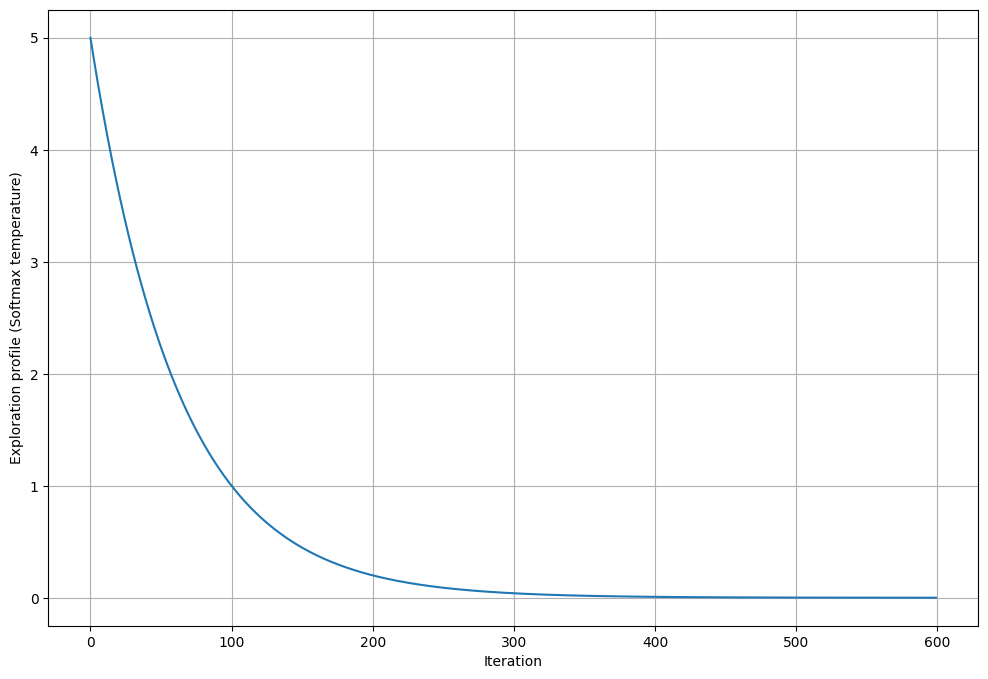

In [23]:
### Define exploration profile
initial_value = 5
#num_iterations = 800
#num_iterations = 10
num_iterations = 600
exp_decay = np.exp(-np.log(initial_value) / num_iterations * 6) # We compute the exponential decay in such a way the shape of the exploration profile does not depend on the number of iterations
exploration_profile = [initial_value * (exp_decay ** i) for i in range(num_iterations)]
score_low_bound = -500#-2000 ###change add score low bound


### Plot exploration profile
plt.figure(figsize=(12,8))
plt.plot(exploration_profile)
plt.grid()
plt.xlabel('Iteration')
plt.ylabel('Exploration profile (Softmax temperature)')

In [24]:
### Create environment
env =  Custom_AcrobotEnv()
env.seed(0) # Set a random seed for the environment (reproducible results)
env.MRAC.adaptation_gain[1]
# Get the shapes of the state space (observation_space) and action space (action_space)
state_space_dim = env.observation_space.shape[0]
action_space_dim = env.action_space.n
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"STATE SPACE SIZE: {state_space_dim}")
print(f"ACTION SPACE SIZE: {action_space_dim}")

STATE SPACE SIZE: 6
ACTION SPACE SIZE: 3


/usr/local/lib/python3.12/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


In [25]:
# Set random seeds
torch.manual_seed(0)
np.random.seed(0)

### PARAMETERS
gamma = 0.99   # gamma parameter for the long term reward
replay_memory_capacity = 10000   # Replay memory capacity
lr = 1e-3 # Optimizer learning rate
target_net_update_steps = 10   # Number of episodes to wait before updating the target network
batch_size = 256   # Number of samples to take from the replay memory for each update
bad_state_penalty = 0   # Penalty to the reward when we are in a bad state (in this case when the pole falls down)
min_samples_for_training = 1000   # Minimum samples in the replay memory to enable the training

In [26]:
### Initialize the replay memory
replay_mem = ReplayMemory(replay_memory_capacity)

### Initialize the policy network
policy_net = DQN(state_space_dim, action_space_dim).to(device)

### Initialize the target network with the same weights of the policy network
target_net = DQN(state_space_dim, action_space_dim).to(device)
target_net.load_state_dict(policy_net.state_dict()) # This will copy the weights of the policy network to the target network

### Initialize the optimizer
optimizer = torch.optim.Adam(policy_net.parameters(), lr=lr) # The optimizer will update ONLY the parameters of the policy network

### Initialize the loss function (Huber loss)
loss_fn = nn.SmoothL1Loss()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [27]:
def update_step(policy_net, target_net, replay_mem, gamma, optimizer, loss_fn, batch_size):

    # Sample the data from the replay memory
    batch = replay_mem.sample(batch_size)
    batch_size = len(batch)
    #print(type(batch)) #batch = np.array(batch)

    # Create tensors for each element of the batch
    states      = torch.tensor([s[0] for s in batch], dtype=torch.float32, device=device)
    actions     = torch.tensor([s[1] for s in batch], dtype=torch.int64, device=device)
    rewards     = torch.tensor([s[3] for s in batch], dtype=torch.float32, device=device)

    # Compute a mask of non-final states (all the elements where the next state is not None)
    non_final_next_states = torch.tensor([s[2] for s in batch if s[2] is not None], dtype=torch.float32, device=device) # the next state can be None if the game has ended
    non_final_mask = torch.tensor([s[2] is not None for s in batch], dtype=torch.bool)

    # Compute all the Q values (forward pass)
    policy_net.train()
    q_values = policy_net(states)
    # Select the proper Q value for the corresponding action taken Q(s_t, a)
    #state_action_values = q_values.gather(1, actions.unsqueeze(1).cuda())
    state_action_values = q_values.gather(1, actions.unsqueeze(1).to(device))
    #er0r
    # Compute the value function of the next states using the target network V(s_{t+1}) = max_a( Q_target(s_{t+1}, a)) )
    with torch.no_grad():
      target_net.eval()
      q_values_target = target_net(non_final_next_states)
    next_state_max_q_values = torch.zeros(batch_size, device=device)
    next_state_max_q_values[non_final_mask] = q_values_target.max(dim=1)[0].detach()

    # Compute the expected Q values
    expected_state_action_values = rewards + (next_state_max_q_values * gamma)
    expected_state_action_values = expected_state_action_values.unsqueeze(1)# Set the required tensor shape

    # Compute the Huber loss
    loss = loss_fn(state_action_values, expected_state_action_values)

    # Optimize the model
    optimizer.zero_grad()
    loss.backward()
    # Apply gradient clipping (clip all the gradients greater than 2 for training stability)
    nn.utils.clip_grad_norm_(policy_net.parameters(), 2)
    optimizer.step()



In [28]:
# Initialize the Gym environment
#env = gym.make('Acrobot-v1')
env =  Custom_AcrobotEnv()
env.seed(0) # Set a random seed for the environment (reproducible results)

# This is for creating the output video in Colab, not required outside Colab
#env = wrap_env(env, video_callable=lambda episode_id: episode_id % 100 == 0) # Save a video every 100 episodes

plotting_rewards=[]

save_observation = []
save_wanted_torque = [0]
save_actual_torque = [0]
save_model_torque = [0]
save_ctrl_voltage = []
save_MRAC_adapt_gains = []
ploting_adapt_coeff=[]


/usr/local/lib/python3.12/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


In [ ]:
initial_not_saved = True
k_hat_print = env.MRAC.mu0
print('Initial adapt. coeffs: ', k_hat_print)
#adaptation_gain = env.MRAC.adaptation_gain
#env.MRAC.adaptation_gain[1] = 0
for episode_num, tau in enumerate(tqdm(exploration_profile)):

    #if episode_num == int(len(exploration_profile)/3):
    #  env.MRAC.adaptation_gain =  adaptation_gain+0

    # Reset the environment and get the initial state
    state = env.reset()
    #state = state[0]###################################################################################################################################################
    # Reset the score. The final score will be the total amount of steps before the pole falls
    score = 0
    done = False
    # Go on until the pole falls off
    while not done:
      k_hat_print = env.MRAC.k_hat.round(2)
      if episode_num == len(exploration_profile) - 1 and initial_not_saved:
        save_MRAC_adapt_gains.append(env.MRAC.k_hat)
        save_observation.append(state)
        u0=env.MRAC.adaptationControlLaw(e=env.MRAC.y-env.MRAC.y_m,
                                              r=env.MRAC.r,y=env.MRAC.y,
                                              w=env.MRAC.w)
        save_ctrl_voltage.append(u0)
        initial_not_saved = False
      #end if

      # Choose the action following the policy
      action, q_values = choose_action_softmax(policy_net, state, temperature=tau)

      # Apply the action and get the next state, the reward and a flag "done" that is True if the game is ended
      next_state, reward, done, info, wanted_torque , actual_torque = env.step(action)#############################################
      if episode_num == len(exploration_profile) - 1 :################################################################################
        save_observation.append(next_state)
        save_wanted_torque.append(wanted_torque)
        save_actual_torque.append(actual_torque)
        save_model_torque.append(env.MRAC.y_m)
        save_ctrl_voltage.append(env.MRAC.u)
        save_MRAC_adapt_gains.append(env.MRAC.k_hat)
      #end if

      # Update the final score (+1 for each step)
      score += reward

      if score<score_low_bound: ##### change  to stop high negative score
        done =True
        #env.MRAC.k_temp = env.MRAC.mu0*1


      #if score<score_low_bound:
      #  env.MRAC.k_hat = env.MRAC.mu0*1
      #env.MRAC.k_temp = env.MRAC.mu0*1

      # Apply penalty for bad state

      if done: # if the pole has fallen down
          reward += bad_state_penalty
          next_state = None

      # Update the replay memory
      replay_mem.push(state, action, next_state, reward)

      # Update the network
      if len(replay_mem) > min_samples_for_training: # we enable the training only if we have enough samples in the replay memory, otherwise the training will use the same samples too often
          update_step(policy_net, target_net, replay_mem, gamma, optimizer, loss_fn, batch_size)

      # Visually render the environment (disable to speed up the training)
      #env.render()

      # Set the current state for the next iteration
      state = next_state

    # Update the target network every target_net_update_steps episodes
    if episode_num % target_net_update_steps == 0 : #score<score_low_bound:
        print('Updating target network...')
        target_net.load_state_dict(policy_net.state_dict()) # This will copy the weights of the policy network to the target network

    ploting_adapt_coeff.append(k_hat_print)
    plotting_rewards.append(score)
    # Print the final score
    print(f"EPISODE: {episode_num + 1} ", " adapt. coeffs at final time step: ", k_hat_print)
    if (episode_num + 1)%10==0:
      k_hat_median = np.median(np.array(ploting_adapt_coeff), axis=0)
      print("median: ", k_hat_median)
      #env.MRAC.mu0 = k_hat_median*1
      #env.MRAC.k_hat = k_hat_median*1
      #env.MRAC.k_temp = k_hat_median*1
    print(f"EPISODE: {episode_num + 1} - FINAL SCORE: {score}") # Print the final score

env.MRAC.keep_coeff = True
env.close()

Initial adapt. coeffs:  [ 0.001 -0.001  0.001  0.001]


  0%|          | 0/600 [00:00<?, ?it/s]

Updating target network...
EPISODE: 1   adapt. coeffs at final time step:  [ 2.28 -1.25  2.12  1.  ]
EPISODE: 1 - FINAL SCORE: -501.0


/tmp/ipykernel_29556/177067022.py:9: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states      = torch.tensor([s[0] for s in batch], dtype=torch.float32, device=device)


EPISODE: 2   adapt. coeffs at final time step:  [ 2.27 -1.25  2.12  1.  ]
EPISODE: 2 - FINAL SCORE: -501.0
EPISODE: 3   adapt. coeffs at final time step:  [ 2.27 -1.25  2.12  1.  ]
EPISODE: 3 - FINAL SCORE: -501.0
EPISODE: 4   adapt. coeffs at final time step:  [ 2.27 -1.25  2.12  1.  ]
EPISODE: 4 - FINAL SCORE: -501.0
EPISODE: 5   adapt. coeffs at final time step:  [ 2.27 -1.25  2.12  1.  ]
EPISODE: 5 - FINAL SCORE: -501.0
EPISODE: 6   adapt. coeffs at final time step:  [ 2.27 -1.25  2.12  1.  ]
EPISODE: 6 - FINAL SCORE: -501.0
EPISODE: 7   adapt. coeffs at final time step:  [ 2.27 -1.25  2.12  1.  ]
EPISODE: 7 - FINAL SCORE: -501.0
EPISODE: 8   adapt. coeffs at final time step:  [ 2.27 -1.25  2.12  1.  ]
EPISODE: 8 - FINAL SCORE: -501.0
EPISODE: 9   adapt. coeffs at final time step:  [ 2.27 -1.25  2.12  1.  ]
EPISODE: 9 - FINAL SCORE: -501.0
EPISODE: 10   adapt. coeffs at final time step:  [ 2.27 -1.25  2.12  1.  ]
median:  [ 2.27 -1.25  2.12  1.  ]
EPISODE: 10 - FINAL SCORE: -483.0


In [ ]:
print("mean: ", (np.array(ploting_adapt_coeff)).mean(axis=0).round(2))
print("median: ", np.median(np.array(ploting_adapt_coeff), axis=0))

mean:  [ 2.27 -1.25  2.12  1.  ]
median:  [ 2.27 -1.25  2.12  1.  ]


In [ ]:
plotting_rewards_test=[]
#env.seed(1) # Set a random seed for the environment (reproducible results)
total_episodes_test = 100
best_score = -501

In [ ]:
print('Test')
for i in range(total_episodes_test):
    state = env.reset()
    #state = np.asarray(state[0])
    #s = np.expand_dims(state, axis=0)
    save_observation_temp = [state]
    save_wanted_torque_temp = [0.0]
    save_actual_torque_temp = [0.0]
    save_model_torque_temp = [0.0]
    save_ctrl_voltage_temp = [0.0]
    save_MRAC_adapt_gains_temp= [env.MRAC.k_hat]
    total_reward = 0
    done = False
    t_=0
    while not done:
        k_hat_print = env.MRAC.k_hat.round(2)
        # Choose the best action (temperature 0)
        action, q_values = choose_action_softmax(policy_net, state, temperature=0)
        next_state, reward, done, _ , wanted_torque , actual_torque= env.step(action)
        save_observation_temp.append(next_state)
        save_wanted_torque_temp.append(wanted_torque)
        save_actual_torque_temp.append(actual_torque)
        save_model_torque_temp.append(env.MRAC.y_m)
        save_ctrl_voltage_temp.append(env.MRAC.u)
        save_MRAC_adapt_gains_temp.append(env.MRAC.k_hat)
        state = next_state
        total_reward += reward
        t_+=1
        if total_reward<score_low_bound: ##### change  to stop high negative score
          done = True

    #save_ctrl_voltage_temp.append(env.DCMotorModel.voltage_input)
    # get best score and update save data
    print(f'Episode {i},'
          f'total_reward: {total_reward:.3f}, Episode Length {t_}')
    print(f"Episode: {i}, ", "adapt. coeffs at final time step: ", k_hat_print)
    if best_score<total_reward:
        save_observation = list(save_observation_temp)
        save_wanted_torque = list(save_wanted_torque_temp)
        save_actual_torque = list(save_actual_torque_temp)
        save_model_torque = list(save_model_torque_temp)
        save_ctrl_voltage = list(save_ctrl_voltage_temp)
        save_MRAC_adapt_gains = list(save_MRAC_adapt_gains_temp)
        best_score = total_reward
        best_episode = i
        print(f"---Best Episode:{best_episode}; Best Score:{best_score}----")
    plotting_rewards_test.append(total_reward)

Test
Episode 0,total_reward: -70.000, Episode Length 71
Episode: 0,  adapt. coeffs at final time step:  [ 2.27 -1.25  2.12  1.  ]
---Best Episode:0; Best Score:-70.0----
Episode 1,total_reward: -87.000, Episode Length 88
Episode: 1,  adapt. coeffs at final time step:  [ 2.27 -1.25  2.12  1.  ]
Episode 2,total_reward: -71.000, Episode Length 72
Episode: 2,  adapt. coeffs at final time step:  [ 2.27 -1.25  2.12  1.  ]
Episode 3,total_reward: -64.000, Episode Length 65
Episode: 3,  adapt. coeffs at final time step:  [ 2.27 -1.25  2.12  1.  ]
---Best Episode:3; Best Score:-64.0----
Episode 4,total_reward: -62.000, Episode Length 63
Episode: 4,  adapt. coeffs at final time step:  [ 2.27 -1.25  2.12  1.  ]
---Best Episode:4; Best Score:-62.0----
Episode 5,total_reward: -97.000, Episode Length 98
Episode: 5,  adapt. coeffs at final time step:  [ 2.27 -1.25  2.12  1.  ]
Episode 6,total_reward: -76.000, Episode Length 77
Episode: 6,  adapt. coeffs at final time step:  [ 2.27 -1.25  2.12  1.  ]


In [ ]:
save_observation_temp = None
save_wanted_torque_temp = None
save_actual_torque_temp = None
save_model_torque_temp = None
save_ctrl_voltage_temp = None
save_MRAC_adapt_gains_temp= None

In [ ]:
# Create a dictionary of variables you want to save

variables_to_save = {
    'plotting_rewards': plotting_rewards,
    'save_observation': save_observation,
    'save_wanted_torque': save_wanted_torque,
    'save_actual_torque': save_actual_torque,
    'save_model_torque': save_model_torque,
    'save_ctrl_voltage': save_ctrl_voltage,
    'plotting_rewards_test':plotting_rewards_test,
    'save_MRAC_adapt_gains': save_MRAC_adapt_gains,
    'ploting_adapt_coeff': ploting_adapt_coeff
}

In [28]:
path = '/content/drive/MyDrive/Colab Notebooks/codes/MRAC/save_data/Acrobot/'

In [ ]:
with open(path+'Acrobot.pkl', 'wb') as f:
    pickle.dump(variables_to_save, f)
print(f"All variables saved to {path+'Acrobot.pkl'}")

All variables saved to /content/drive/MyDrive/Colab Notebooks/codes/MRAC/save_data/Acrobot/Acrobot.pkl


In [ ]:
torch.save(policy_net, path+"policy_net.pickle")

In [29]:
path = '/content/drive/MyDrive/Colab Notebooks/codes/MRAC/save_data/Acrobot/'

In [30]:
# Open the file in read-binary mode and load the dictionary
with open(path+'Acrobot.pkl', 'rb') as f:
    loaded_variables = pickle.load(f)

# Access the loaded variables
plotting_rewards = loaded_variables['plotting_rewards']
save_observation = loaded_variables['save_observation']
save_wanted_torque = loaded_variables['save_wanted_torque']
save_actual_torque = loaded_variables['save_actual_torque']
save_model_torque = loaded_variables['save_model_torque']
save_ctrl_voltage = loaded_variables['save_ctrl_voltage']
plotting_rewards_test = loaded_variables['plotting_rewards_test']
save_MRAC_adapt_gains = loaded_variables['save_MRAC_adapt_gains']
ploting_adapt_coeff = loaded_variables['ploting_adapt_coeff']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
policy_net_temp = torch.load(path+"policy_net.pickle",weights_only=False).to(device)

In [31]:
plt.rc('text.latex', preamble=r'\usepackage{amsmath,amssymb,amsfonts}')
#plt.rcParams["text.usetex"]=False
#plt.rcParams["font.family"] = "sans-serif"
#plt.rcParams["font.family"] = "serif"
#plt.rcParams['mathtext.fontset'] = 'cm'
#plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

In [32]:
def unnorm_to_norm(x):
  y = (x-low_bound_reward_list)/(up_bound_reward_list-low_bound_reward_list)
  return y

In [33]:
def norm_to_unnorm(y):
  x=y*(up_bound_reward_list-low_bound_reward_list)+low_bound_reward_list
  return x

In [34]:
low_bound_reward_list = -500 # -0.1*(1**2 force mag)*(1000*episoded)s
up_bound_reward_list = 0
print("low_bound_reward_list=",low_bound_reward_list)
print("up_bound_reward_list=",up_bound_reward_list)
norm_reward_list = np.array(plotting_rewards)
norm_reward_list = unnorm_to_norm(norm_reward_list)

low_bound_reward_list= -500
up_bound_reward_list= 0


/tmp/ipykernel_2727/252990024.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


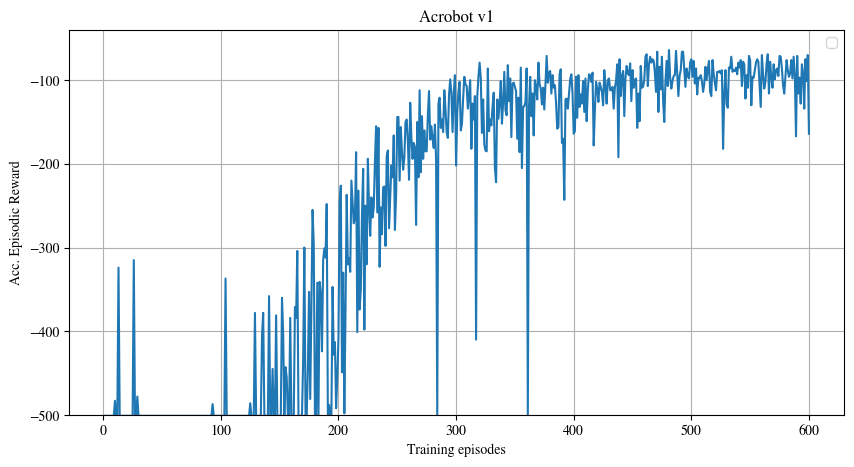

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(range(1,num_iterations+1),plotting_rewards)
plt.xlabel('Training episodes')
plt.ylabel('Acc. Episodic Reward')
plt.ylim([-500,-40])
plt.legend()
plt.title('Acrobot v1')
plt.grid()
plt.show()

In [36]:
print(type(plotting_rewards))

<class 'list'>


In [37]:
N=50

In [38]:
# Compute the moving average of the last 50 numbers
moving_average = []
for i, n in enumerate(plotting_rewards):
    if i < N:
        # If there are not enough previous elements,
        # append the average of all available elements
        avg = sum(plotting_rewards[:i+1]) / (i+1)
    else:
        # Otherwise, compute the average of the previous 5 elements
        avg = sum(plotting_rewards[i-50:i+1]) / 50
    moving_average.append(avg)



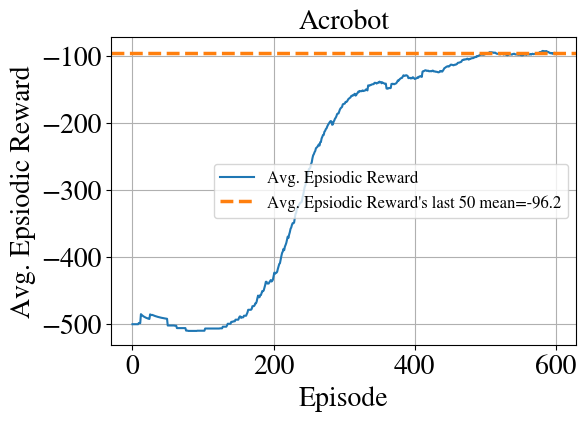

In [39]:
# Plot the moving average

font = {'size': 20}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(6)
f.set_figheight(4)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

#plt.plot(moving_average)
plt.plot(moving_average, label = "Avg. Epsiodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(moving_average)[-N:-1].mean(), linestyle='--',
            label = "Avg. Epsiodic Reward's last " +str(N) +" mean="+f"{np.array(moving_average)[-N:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Episode")
plt.ylabel("Avg. Epsiodic Reward")
plt.legend(fontsize=12)
plt.grid()
plt.title('Acrobot',fontsize=20)
plt.show()

In [40]:
# Compute the moving average of the last 50 numbers
moving_average = []
for i, n in enumerate(norm_reward_list):
    if i < 50:
        # If there are not enough previous elements,
        # append the average of all available elements
        avg = sum(norm_reward_list[:i+1]) / (i+1)
    else:
        # Otherwise, compute the average of the previous 5 elements
        avg = sum(norm_reward_list[i-50:i+1]) / 50
    moving_average.append(avg)

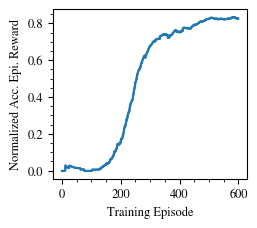

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [41]:
# Plot the moving average

font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)
plt.plot(moving_average)
plt.plot(moving_average, label = "Normalized Acc. Epi. Reward",color="C0",linewidth = 1.5)
#plt.axhline(y=np.array(moving_average[-20:-1]).mean(), linestyle='--',
#            label = "Acc. Episodic Reward's last 20 mean= "+f"{np.array(moving_average[-20:-1]).mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Training Episode")
plt.ylabel("Normalized Acc. Epi. Reward")
#plt.grid()
plt.minorticks_on()
#plt.yticks(np.arange(0.0, 1.0, 0.1))
#plt.legend()
plt.savefig(path+"Acrobot_Acc_Reward_vs_Episode.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [42]:
print("Normalized Acc. Episodic Reward's last 20 mean=")
print(np.array(moving_average[-20:-1]).mean())

Normalized Acc. Episodic Reward's last 20 mean=
0.8310736842105262


/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1987: PyparsingDeprecationWarning: 'setParseA

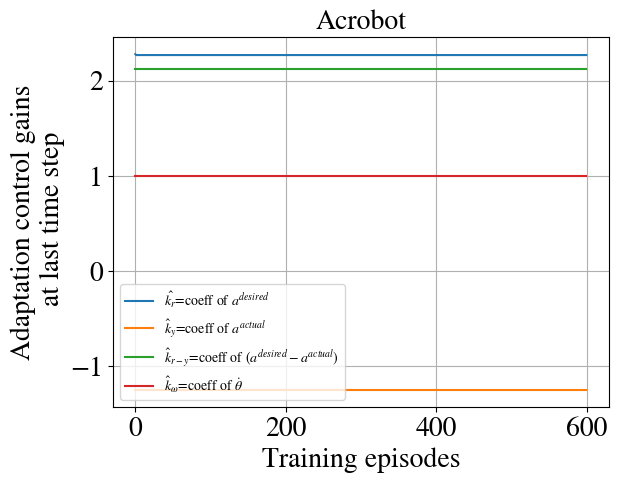

In [43]:
font = {'size': 20}
plt.rc('font', **font)
plt.plot(ploting_adapt_coeff)
plt.xlabel("Training episodes")
plt.ylabel("Adaptation control gains\n at last time step")
#plt.rc('axes', labelsize=30)

plt.grid()
plt.title('Acrobot',fontsize=20)
plt.legend(labels=[r"$\hat{k_r}$=coeff of $a^{desired}$",
                   r"$\hat{k}_y$=coeff of $a^{actual}$",
                 r"$\hat{k}_{r-y}$=coeff of $(a^{desired}-a^{actual})$",
                 r"$\hat{k}_\omega$=coeff of $\dot{\theta}$"], fontsize=10)
plt.show()

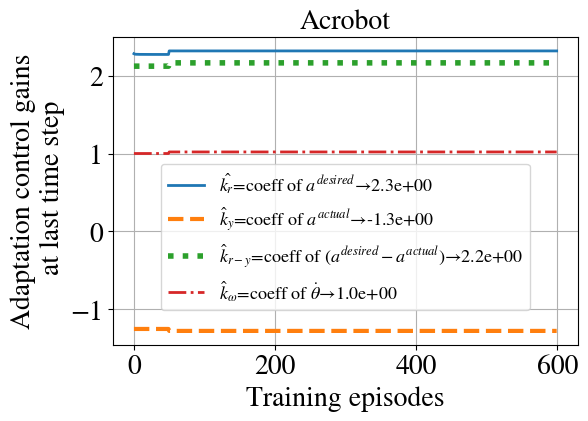

In [44]:
N=50
# Compute the moving average of the last 50 numbers
moving_average = []
for i, n in enumerate(ploting_adapt_coeff):
    if i < N:
        # If there are not enough previous elements,
        # append the average of all available elements
        avg = sum(ploting_adapt_coeff[:i+1]) / (i+1)
    else:
        # Otherwise, compute the average of the previous 5 elements
        avg = sum(ploting_adapt_coeff[i-N:i+1]) / N
    moving_average.append(avg)
moving_average = np.array(moving_average).T
# Plot the moving average
font = {'size': 20}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(6)
f.set_figheight(4)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

plt.plot(moving_average[0]
         ,label = r"$\hat{k_r}$=coeff of $a^{desired}$"+f"→{moving_average[0,-5:-1].mean():.1e}",color="C0",linewidth = 2)
plt.plot(moving_average[1],'--',
         label = r"$\hat{k}_y$=coeff of $a^{actual}$"+f"→{moving_average[1,-5:-1].mean():.1e}",color="C1",linewidth = 3)
plt.plot(moving_average[2],':',
         label = r"$\hat{k}_{r-y}$=coeff of $(a^{desired}-a^{actual})$"+f"→{moving_average[2,-5:-1].mean():.1e}",color="C2",linewidth = 4)
plt.plot(moving_average[3],'-.',
         label = r"$\hat{k}_\omega$=coeff of $\dot{\theta}$"+f"→{moving_average[3,-5:-1].mean():.1e}",color="C3",linewidth = 2)
#plt.plot(moving_average)
plt.xlabel("Training episodes")
plt.ylabel("Adaptation control gains\n at last time step")
plt.title('Acrobot',fontsize=20)
plt.grid()
#plt.yticks(np.arange(-1, 3.1, 1))
plt.legend(fontsize=13, bbox_to_anchor=(0.5, 0.35), loc='center')
plt.show()

In [45]:
# Test Histogram
norm_ep_reward_list_test = np.array(plotting_rewards_test)
norm_ep_reward_list_test = unnorm_to_norm(norm_ep_reward_list_test)
print(norm_ep_reward_list_test.max())
print(norm_ep_reward_list_test.min())
min_bin = np.floor(norm_ep_reward_list_test.min()*100)/100
print(min_bin)

0.876
0.72
0.72


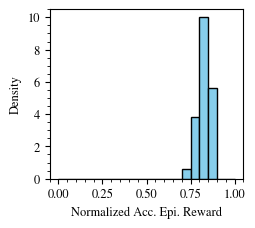

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [46]:
font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)
data_rewards = np.array(norm_ep_reward_list_test)
density_True = True
plt.hist(data_rewards, bins=np.arange(0,1.01,0.05), density=density_True ,color='skyblue', edgecolor='black')
plt.xlabel('Normalized Acc. Epi. Reward')
ylabel='Density'if density_True else 'Frequency'
plt.ylabel(ylabel)
#plt.xticks(np.arange(0.0,1.01,0.1))
#plt.xticks(np.arange(0,1.00001,0.05),minor=True)
plt.minorticks_on()
plt.savefig(path+"Acrobot_Acc_Reward_vs_Episode_Test_Hist.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [47]:
print("Test Normalized Acc Episodic Reward's Results:")
print(f"Unnormalized: max={norm_to_unnorm(data_rewards).max():.3f} ,mean={norm_to_unnorm(data_rewards).mean():.3f}, std={norm_to_unnorm(data_rewards).std():.3f}")
print(f"Normalized:   max={data_rewards.max():.3e} ,mean={data_rewards.mean():.3e}, std={data_rewards.std():.3e}")

Test Normalized Acc Episodic Reward's Results:
Unnormalized: max=-62.000 ,mean=-87.710, std=17.469
Normalized:   max=8.760e-01 ,mean=8.246e-01, std=3.494e-02


In [48]:
dt=env.dt

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarnin

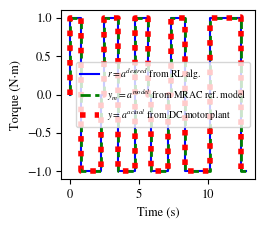

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [49]:
time_ = np.linspace(start = 0, stop = len(save_actual_torque)* dt,num=len(save_actual_torque) )

font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')


plt.step(time_, save_wanted_torque ,label = r"$r=a^{desired}$ from RL alg.",color="blue",linewidth = 1.5)
plt.step(time_, save_model_torque , '--',label = "$y_m=a^{model}$ from MRAC ref. model",color="green",linewidth = 2)
plt.step(time_, save_actual_torque , ':',label = "$y=a^{actual}$ from DC motor plant",color="red",linewidth = 4)
plt.xlabel("Time (s)")
plt.ylabel(r"Torque (N⋅m)")
#plt.title('Acrobot',fontsize=20)
plt.legend(fontsize=7)#,bbox_to_anchor=(1.05, 1.0), loc='upper left')
#plt.legend(fontsize=8.5)
plt.savefig(path+"Acrobot_Torque_vs_Time.pdf", format='pdf', bbox_inches='tight')
#plt.grid()
plt.show()

In [50]:
e_ry=np.array(save_wanted_torque)-np.array(save_actual_torque)
e_yy_m=np.array(save_actual_torque)-np.array(save_model_torque)
print(f"e_ry: (mean, std, mae) = ({e_ry.mean():.2e}, {e_ry.std():.2e}, {np.abs(e_ry).mean():.2e})")
print(f"e_yy_m: (mean, std, mae) = ({e_yy_m.mean():.2e}, {e_yy_m.std():.2e}, {np.abs(e_yy_m).mean():.2e})")

e_ry: (mean, std, mae) = (5.79e-05, 3.78e-03, 3.60e-03)
e_yy_m: (mean, std, mae) = (-5.87e-05, 3.79e-03, 3.61e-03)


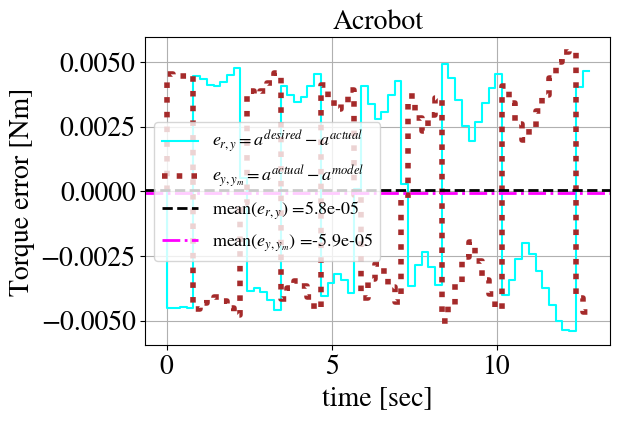

In [51]:
font = {'size': 20}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(6)
f.set_figheight(4)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

e_ry=np.array(save_wanted_torque)-np.array(save_actual_torque)
e_yy_m=np.array(save_actual_torque)-np.array(save_model_torque)


plt.step(time_, e_ry ,label = "$e_{r,y}=a^{desired}-a^{actual}$ ",color="cyan",linewidth = 1.5)
plt.step(time_, e_yy_m , ':',label = "$e_{y,y_m}=a^{actual}-a^{model}$ ",color="brown",linewidth = 4)
plt.axhline(y=e_ry.mean(), color="black",linewidth = 2, linestyle='--', label='mean($e_{r,y}$) =' +f'{e_ry.mean():.1e}')
plt.axhline(y=e_yy_m.mean(), color="magenta",linewidth = 2, linestyle='-.', label='mean($e_{y,y_m}$) =' +f'{e_yy_m.mean():.1e}')
plt.title('Acrobot',fontsize=20)


plt.xlabel("time [sec]")
plt.ylabel("Torque error [Nm]")
plt.legend(fontsize=13)
plt.grid()
plt.show()

In [52]:
from scipy.integrate import cumulative_trapezoid

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


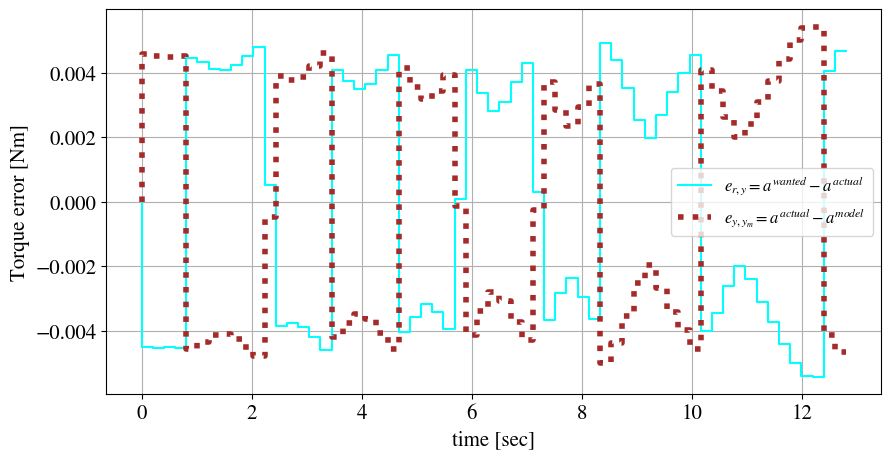

In [53]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

e_ry=np.array(save_wanted_torque)-np.array(save_actual_torque)
e_yy_m=np.array(save_actual_torque)-np.array(save_model_torque)

plt.step(time_, e_ry ,label = r"$e_{r,y}=a^{wanted}-a^{actual}$ ",color="cyan",linewidth = 1.5)
plt.step(time_, e_yy_m , ':',label = "$e_{y,y_m}=a^{actual}-a^{model}$ ",color="brown",linewidth = 4)

plt.xlabel("time [sec]")
plt.ylabel("Torque error [Nm]")
plt.legend(fontsize=12)
plt.grid()
plt.show()

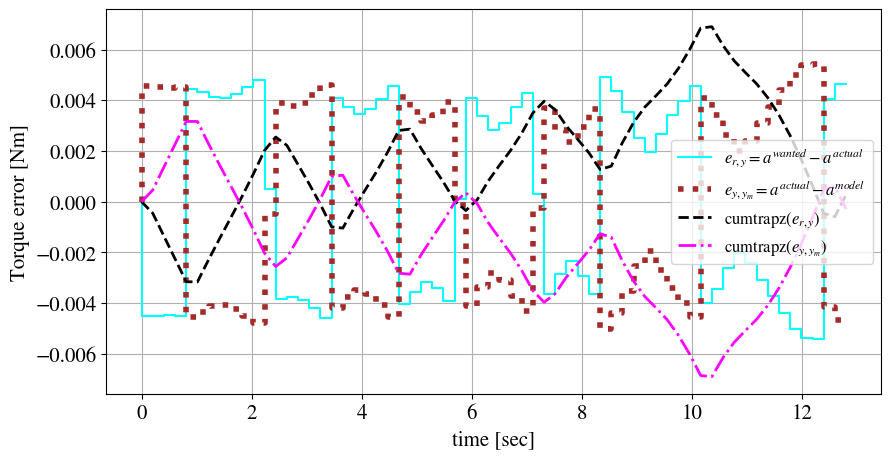

In [54]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

e_ry=np.array(save_wanted_torque)-np.array(save_actual_torque)
e_yy_m=np.array(save_actual_torque)-np.array(save_model_torque)

cum_trapz_e_ry = cumulative_trapezoid(y=np.r_[0,e_ry],x=None, dx=dt)
cum_trapz_e_yy_m = cumulative_trapezoid(y=np.r_[0,e_yy_m],x=None, dx=dt)


plt.step(time_, e_ry ,label = r"$e_{r,y}=a^{wanted}-a^{actual}$ ",color="cyan",linewidth = 1.5)
plt.step(time_, e_yy_m , ':',label = "$e_{y,y_m}=a^{actual}-a^{model}$ ",color="brown",linewidth = 4)

plt.plot(time_, cum_trapz_e_ry,'--',
         label = r"cumtrapz($e_{r,y}$)",color="black",linewidth = 2)
plt.plot(time_, cum_trapz_e_yy_m,'-.',
         label = r"cumtrapz($e_{y,y_m}$)",color="magenta",linewidth = 2)

plt.xlabel("time [sec]")
plt.ylabel("Torque error [Nm]")
plt.legend(fontsize=12)
plt.grid()
plt.show()

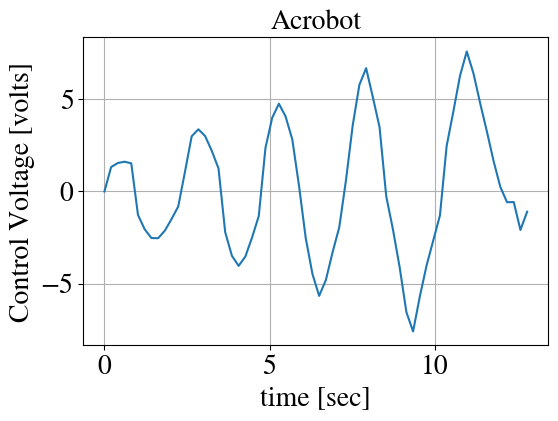

In [55]:
font = {'size': 20}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(6)
f.set_figheight(4)

plt.plot(time_, save_ctrl_voltage)
plt.xlabel("time [sec]")
plt.ylabel("Control Voltage [volts]")
plt.title('Acrobot',fontsize=20)
plt.grid()
plt.show()

In [56]:
np_array_MRAC_adapt_gains = np.array(save_MRAC_adapt_gains).T

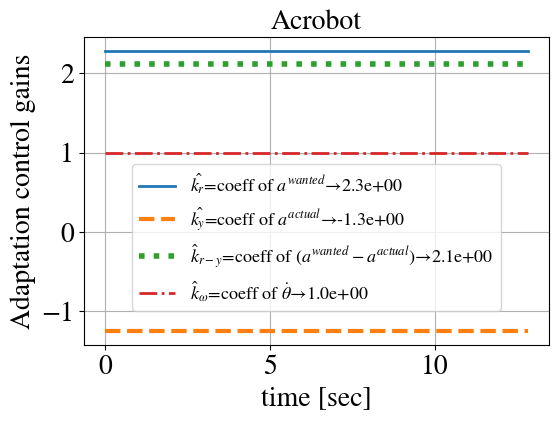

In [57]:
font = {'size': 20}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(6)
f.set_figheight(4)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

plt.plot(time_, np_array_MRAC_adapt_gains[0]
         ,label = r"$\hat{k_r}$=coeff of $a^{wanted}$"+f"→{np_array_MRAC_adapt_gains[0,-20:-1].mean():.1e}",color="C0",linewidth = 2)
plt.plot(time_, np_array_MRAC_adapt_gains[1],'--'
         ,label = r"$\hat{k_y}$=coeff of $a^{actual}$"+f"→{np_array_MRAC_adapt_gains[1,-20:-1].mean():.1e}",color="C1",linewidth = 3)
plt.plot(time_, np_array_MRAC_adapt_gains[2],':',
         label = r"$\hat{k}_{r-y}$=coeff of $(a^{wanted}-a^{actual})$"+f"→{np_array_MRAC_adapt_gains[2,-20:-1].mean():.1e}",color="C2",linewidth = 4)
plt.plot(time_, np_array_MRAC_adapt_gains[3],'-.',
         label = r"$\hat{k}_\omega$=coeff of $\dot{\theta}$"+f"→{np_array_MRAC_adapt_gains[3,-20:-1].mean():.1e}",color="C3",linewidth = 2)
plt.xlabel("time [sec]")
plt.ylabel("Adaptation control gains")
plt.title('Acrobot',fontsize=20)
plt.grid()
#plt.yticks(np.arange(-1, 3.1, 1))
plt.legend(fontsize=13, bbox_to_anchor=(0.5, 0.35), loc='center')
plt.show()

In [58]:
import math

cos_theta_1 = []
sin_theta_1 = []
cos_theta_2 = []
sin_theta_2 = []
ang_vel_theta_1 = []
ang_vel_theta_2 = []

for observ in save_observation:
  for index,value in enumerate(observ):
    if index == 0:
      cos_theta_1.append(value)
    if index == 1:
      sin_theta_1.append(value)
    if index == 2:
      cos_theta_2.append(value)
    if index == 3:
      sin_theta_2.append(value)
    if index == 4:
      ang_vel_theta_1.append(value)
    if index == 5:
      ang_vel_theta_2.append(value)

In [59]:
cos_theta_1 = np.array(cos_theta_1)
cos_theta_2 = np.array(cos_theta_2)
sin_theta_1 = np.array(sin_theta_1)
sin_theta_2 = np.array(sin_theta_2)
ang_vel_theta_1 = np.array(ang_vel_theta_1)
ang_vel_theta_2 = np.array(ang_vel_theta_2)

In [60]:
print(len(cos_theta_1))

64


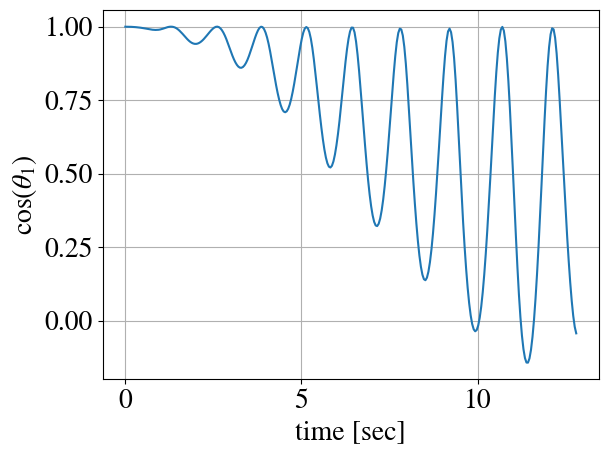

In [61]:
from scipy.interpolate import make_interp_spline, BSpline

time_cos_theta_1 = np.linspace(start = 0, stop = len(cos_theta_1)* dt,num=len(cos_theta_1))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_cos_theta_1[-1] , 300)

spl = make_interp_spline(time_cos_theta_1, cos_theta_1, k=3)  # type: BSpline
power_smooth = spl(xnew)

plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel("time [sec]")
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel(r'$\cos({\theta_1})$')
plt.show()

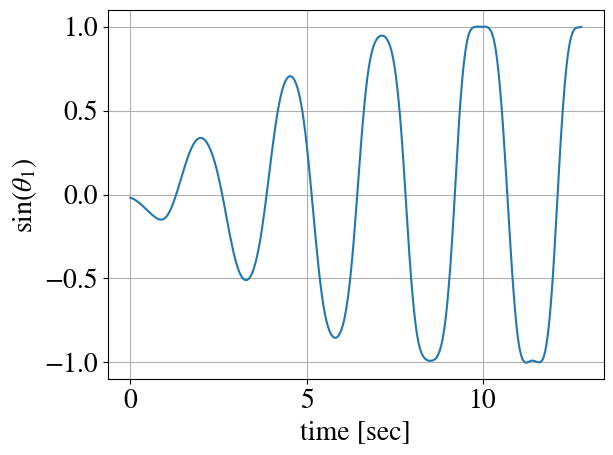

In [62]:
from scipy.interpolate import make_interp_spline, BSpline

time_sin_theta_1 = np.linspace(start = 0, stop = len(sin_theta_1)* dt,num=len(sin_theta_1))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_sin_theta_1[-1] , 300)

spl = make_interp_spline(time_sin_theta_1, sin_theta_1, k=3)  # type: BSpline
power_smooth = spl(xnew)

plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel("time [sec]")
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel(r'$\sin({\theta_1})$')
plt.show()

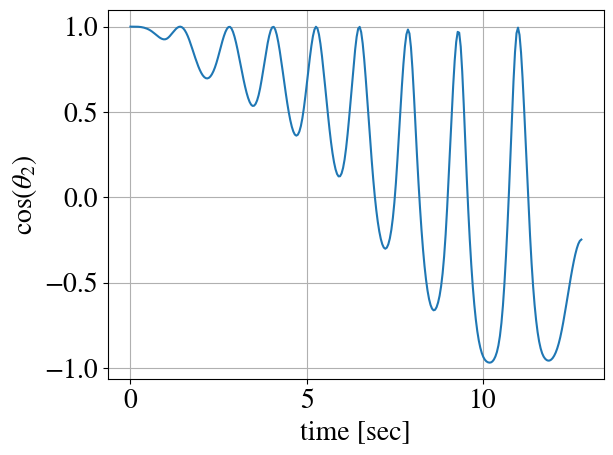

In [63]:
from scipy.interpolate import make_interp_spline, BSpline

time_cos_theta_2 = np.linspace(start = 0, stop = len(cos_theta_2)* dt,num=len(cos_theta_2))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_cos_theta_2[-1] , 300)

spl = make_interp_spline(time_cos_theta_2, cos_theta_2, k=3)  # type: BSpline
power_smooth = spl(xnew)

plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel("time [sec]")
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel(r'$\cos({\theta_2})$')
plt.show()

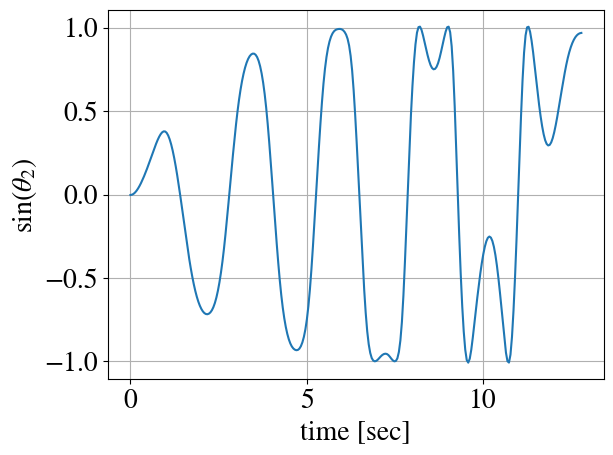

In [64]:
from scipy.interpolate import make_interp_spline, BSpline

time_sin_theta_2 = np.linspace(start = 0, stop = len(sin_theta_2)* dt,num=len(sin_theta_2))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_sin_theta_2[-1] , 300)

spl = make_interp_spline(time_sin_theta_2, sin_theta_2, k=3)  # type: BSpline
power_smooth = spl(xnew)

plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel("time [sec]")
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel(r'$\sin({\theta_2})$')
plt.show()

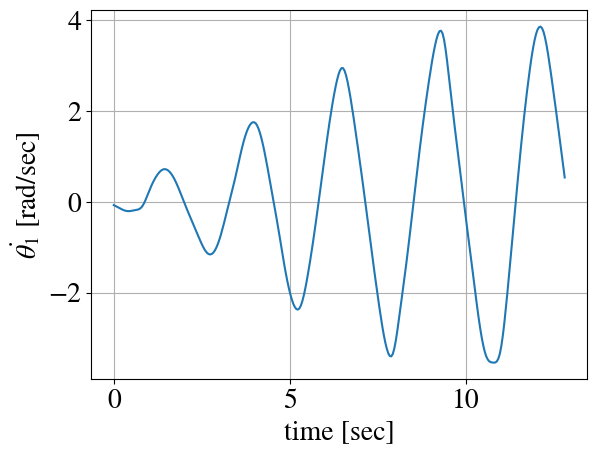

In [65]:
from scipy.interpolate import make_interp_spline, BSpline

time_ang_vel_theta_1 = np.linspace(start = 0, stop = len(ang_vel_theta_1)* dt,num=len(ang_vel_theta_1))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_ang_vel_theta_1[-1] , 300)

spl = make_interp_spline(time_ang_vel_theta_1, ang_vel_theta_1, k=3)  # type: BSpline
power_smooth = spl(xnew)

plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel("time [sec]")
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel(r'$\dot{\theta_1}$ [rad/sec]')
plt.show()

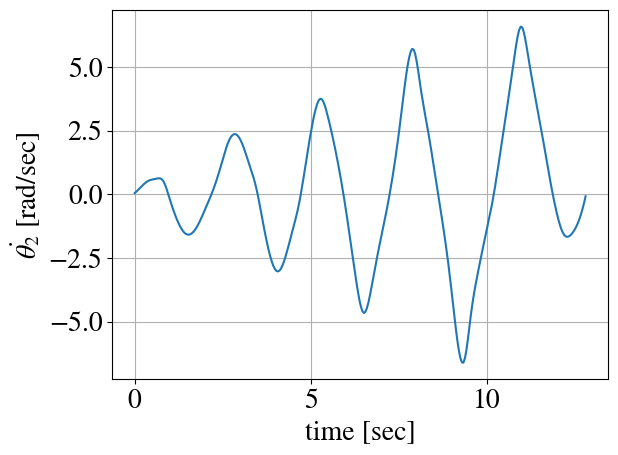

In [66]:
from scipy.interpolate import make_interp_spline, BSpline

time_ang_vel_theta_2 = np.linspace(start = 0, stop = len(ang_vel_theta_2)* dt,num=len(ang_vel_theta_2))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_ang_vel_theta_2[-1] , 300)

spl = make_interp_spline(time_ang_vel_theta_2, ang_vel_theta_2, k=3)  # type: BSpline
power_smooth = spl(xnew)

plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel("time [sec]")
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel(r'$\dot{\theta_2}$ [rad/sec]')
plt.show()

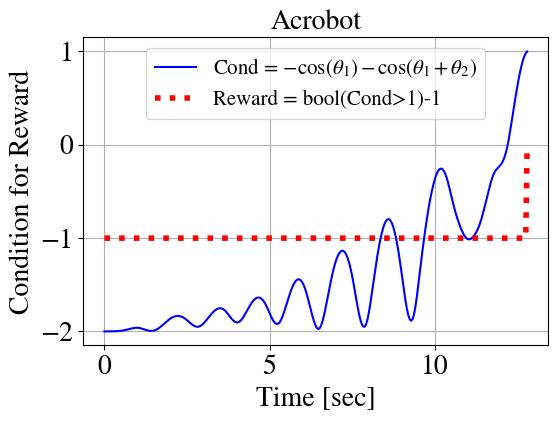

In [67]:
Condition = -cos_theta_1 -cos_theta_1*cos_theta_2 + sin_theta_1*sin_theta_2
spl = make_interp_spline(time_sin_theta_2, Condition, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 20}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(6)
f.set_figheight(4)

plt.plot(xnew, power_smooth, label = r'Cond = $-\cos(\theta_1)-\cos({\theta_1+\theta_2})$',color="blue")
plt.plot(xnew, (power_smooth>1)-1,':', label = r'Reward = bool(Cond>1)-1',color="red", linewidth = 4)

plt.grid()
#plt.legend()
plt.xlabel("Time [sec]")
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel('Condition for Reward')
plt.title('Acrobot',fontsize=20)
plt.legend(fontsize=15, bbox_to_anchor=(0.5, 0.85), loc='center')
plt.show()

In [68]:
# Initialize the Gym environment
env =  Custom_AcrobotEnv()
env.seed(1) # Set a random seed for the environment (reproducible results)

# This is for creating the output video in Colab, not required outside Colab
#env = wrap_env(env, video_callable=lambda episode_id: True) # Save a video every episode

plotting_rewards2=[]
# Let's try for a total of 10 episodes
for num_episode in range(10):
    # Reset the environment and get the initial state
    state = env.reset()
    #state = state[0]##################################################################################################################################
    # Reset the score. The final score will be the total amount of steps before the pole falls
    score = 0
    done = False
    # Go on until the pole falls off or the score reach 490
    while not done:
      # Choose the best action (temperature 0)
      action, q_values = choose_action_softmax(policy_net, state, temperature=0)
      #action, q_values = choose_action_softmax(target_net, state, temperature=0)

      # Apply the action and get the next state, the reward and a flag "done" that is True if the game is ended
      next_state, reward, done, info , wanted_torque, actual_torque = env.step(action)
      # Visually render the environment
      #env.render()
      # Update the final score (+1 for each step)
      score += reward
      # Set the current state for the next iteration
      state = next_state
      # Check if the episode ended (the pole fell down)
      if score<=-500:#score_low_bound: ##### change  to stop high negative score
        done =True
    # Print the final score
    plotting_rewards2.append(score)
    print(f"EPISODE {num_episode + 1} - FINAL SCORE: {score}")
env.close()

/usr/local/lib/python3.12/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


EPISODE 1 - FINAL SCORE: -500.0
EPISODE 2 - FINAL SCORE: -500.0
EPISODE 3 - FINAL SCORE: -500.0
EPISODE 4 - FINAL SCORE: -500.0
EPISODE 5 - FINAL SCORE: -500.0
EPISODE 6 - FINAL SCORE: -500.0
EPISODE 7 - FINAL SCORE: -500.0
EPISODE 8 - FINAL SCORE: -500.0
EPISODE 9 - FINAL SCORE: -500.0
EPISODE 10 - FINAL SCORE: -500.0


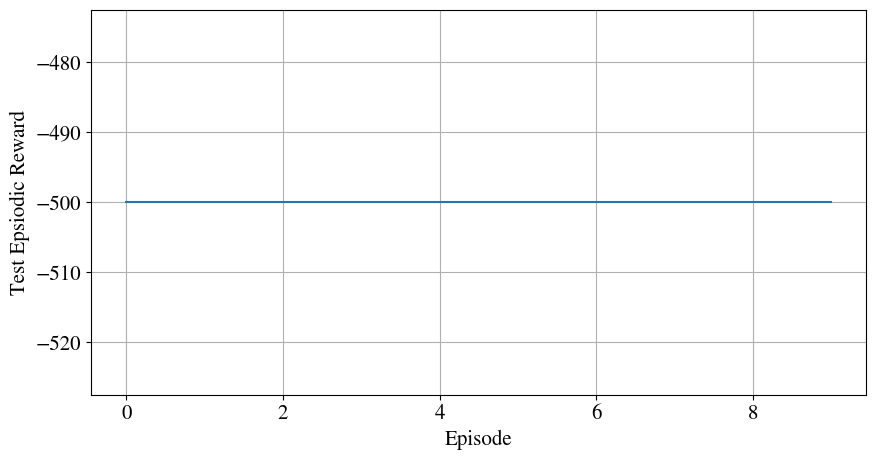

In [69]:

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(plotting_rewards2)
plt.xlabel("Episode")
plt.ylabel("Test Epsiodic Reward")
plt.grid()
plt.show()